# <span style=color:yellow;>HW Musical Note Frequency Visualization

## Objective

Create a Python script from scratch that generates and visualizes the frequencies of musical notes across multiple octaves, highlighting key features like the audible range, concert pitch (A4 = 440 Hz), and octave groupings. 

This task will reinforce your understanding of scientific pitch notation (SPN), frequency relationships, and data visualization with `matplotlib`.  

## Requirements:

1. **Generate Musical Notes & Frequencies**:  
   - Include all 12 notes in an octave (C, C#, D, D#, E, F, F#, G, G#, A, A#, B) across octaves 1 to 8 (e.g., C1 to B8).  
   - Calculate their frequencies using the `librosa.note_to_hz()` function (ensure you install `librosa` first: `pip install librosa`).  
   - Filter notes to only include those within the human audible range (20 Hz to 20,000 Hz).  

2. **Visualization Specifications**:  
   - Create a plot where:  
     - The x-axis shows note names in SPN (e.g., C4, D#5).  
     - The y-axis shows frequency in Hz (use a linear scale).  
   - Use vertical lines to represent each note’s frequency (from y=0 to the note’s frequency).  
   - Add markers (e.g., circles) at the top of each vertical line to highlight the frequency value.  
   - Color-code lines/markers by octave (e.g., all octave 4 notes share a color).  

3. **Key Reference Annotations**:  
   - Add horizontal lines and labels for:  
     - The lower limit of human hearing (20 Hz).  
     - The upper limit of human hearing (20,000 Hz).  
     - Concert pitch (A4 = 440 Hz) – use a distinct color (e.g., red) for this.

4. **Formatting & Readability**:  
   - Include a title (e.g., "Musical Notes in the Audible Range (20–20,000 Hz)").  
   - Label the x-axis ("Musical Note (Scientific Pitch Notation)") and y-axis ("Frequency (Hz)").  
   - Rotate x-axis labels for readability (since there are many notes).  
   - Add a legend that maps colors to octaves (e.g., "Octave 1", "Octave 2", etc.).  
   - Adjust the plot layout to prevent clipping (e.g., use `subplots_adjust()` to add padding).  

**Deliverables:**  
- A single Python script (`.py` file) with all code written from scratch (no copying/pasting from external sources).  
- The script must be self-contained (include comments explaining key steps).  
- When run, it should display a clear, labeled plot meeting all specifications.  

## Deadline: 
Noon (12:00 PM) this coming Sunday.  

## Hints: 

- Use `librosa.note_to_hz(note_name)` to convert SPN note names (e.g., "A4") to frequencies.  
- Sort notes by frequency to ensure they appear in order on the x-axis.  
- Use `matplotlib`’s `scatter()` for markers and `plot()` for vertical lines.  
- For color-coding, map each octave to a unique color using a palette (e.g., `sns.color_palette()` from `seaborn`).  

## Evaluation Criteria:

- Correct generation and filtering of notes/frequencies.  
- Clear, well-labeled visualization with all required elements.  
- Code readability (comments, logical structure).  
- Adherence to the deadline.  

Good luck!

# Generate Musical Notes & Frequencies

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import librosa
from IPython.display import display
from audio_visualization import * 

In [31]:
# Define all notes in an octave
notes_in_octave = ["C", "C#", "D", "D#", "E", "F", 
                   "F#", "G", "G#", "A", "A#", "B"]

# Generate notes across octaves 1 to 8
all_notes = [f"{note}{octave}" for octave in range(1, 9) for note in notes_in_octave]

# Get frequencies using librosa
frequencies = librosa.note_to_hz(all_notes)

# Create a DataFrame and filter for human hearing range
df = pd.DataFrame({"Note": all_notes, "Frequency (Hz)": frequencies})
df_filtered = df[(df["Frequency (Hz)"] >= 20) & (df["Frequency (Hz)"] <= 20000)].reset_index(drop=True)

# Display frequencies
display(df_filtered)


,Note,Frequency (Hz)
0,C1,32.703196
1,C#1,34.647829
2,D1,36.708096
3,D#1,38.890873
4,E1,41.203445
...,...,...
91,G8,6271.926976
92,G#8,6644.875161
93,A8,7040.000000
94,A#8,7458.620184


# Visualize Specifications & Key Reference Annotations

C:\Users\saltz\AppData\Local\Temp\ipykernel_34644\2942151677.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("Set2", len(unique_octaves))


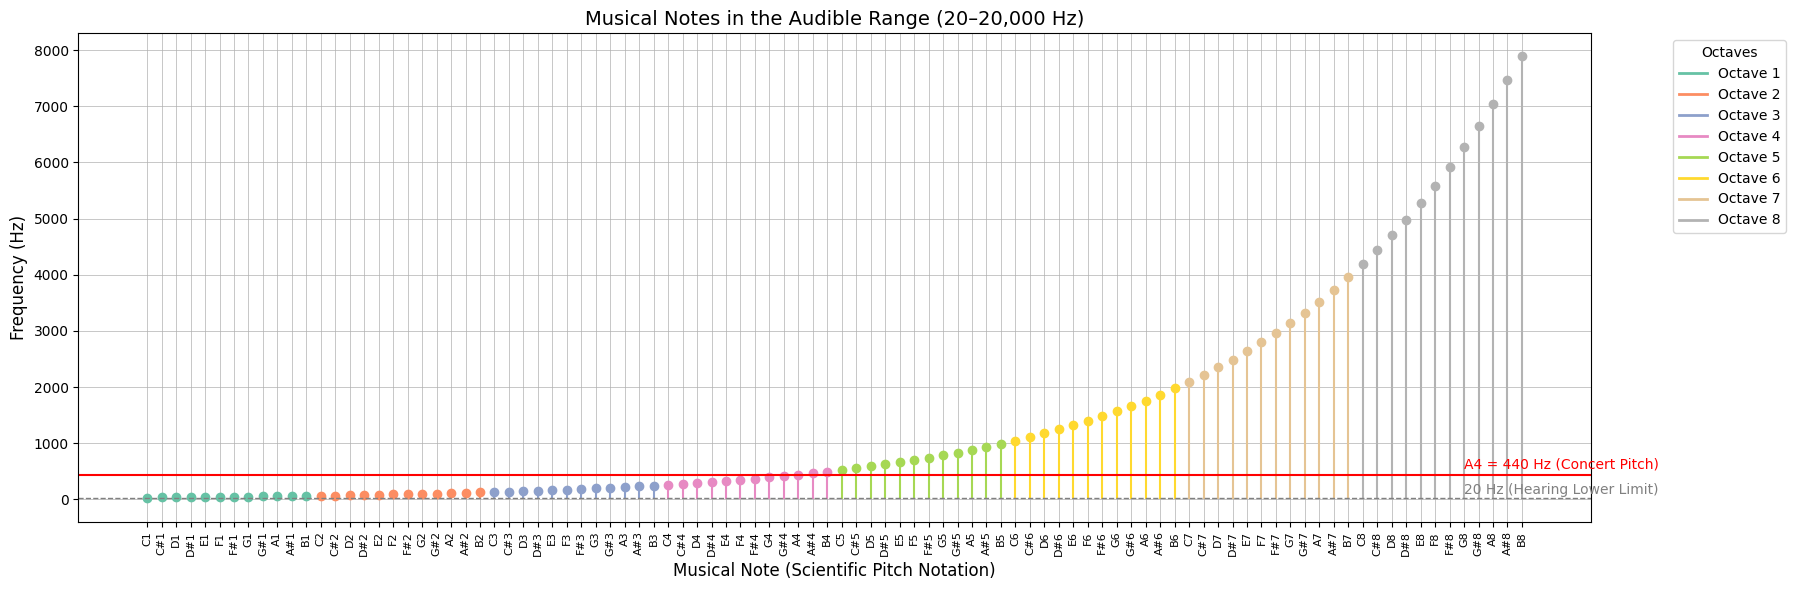

In [32]:

notes = df_filtered["Note"]
freqs = df_filtered["Frequency (Hz)"]

# 提取八度信息，用于配色
octaves = [int(note[-1]) for note in notes]
unique_octaves = sorted(set(octaves))

# 颜色映射
colors = cm.get_cmap("Set2", len(unique_octaves))
octave_color_map = {octave: colors(i) for i, octave in enumerate(unique_octaves)}
note_colors = [octave_color_map[octave] for octave in octaves]

# 绘制竖线 & 顶端圆点
plt.figure(figsize=(18, 6))
for note, freq, color in zip(notes, freqs, note_colors):
    plt.vlines(note, 0, freq, color=color, linewidth=1.5)
    plt.plot(note, freq, "o", color=color)

# 绘制参考线
plt.axhline(20, color="gray", linestyle="--", linewidth=1)
plt.text(len(notes)-5, 20+30, "20 Hz (Hearing Lower Limit)", color="gray", fontsize=10, va="bottom")

# 这里不绘制人耳听觉上限线，因为绘制后会导致图被压缩得很矮
# plt.axhline(20000, color="gray", linestyle="--", linewidth=1)
# plt.text(len(notes)-5, 20000-1000, "20,000 Hz (Hearing Upper Limit)", color="gray", fontsize=10, va="top")

# A4 = 440 Hz
plt.axhline(440, color="red", linestyle="-", linewidth=1.5)
plt.text(len(notes)-5, 440+50, "A4 = 440 Hz (Concert Pitch)", color="red", fontsize=10, va="bottom")

# 标签 & 网格线 & 样式
plt.xticks(rotation=90, fontsize=8)
plt.grid(True, axis="both", linewidth=0.5)
plt.xlabel("Musical Note (Scientific Pitch Notation)", fontsize=12)
plt.ylabel("Frequency (Hz)", fontsize=12)
plt.title("Musical Notes in the Audible Range (20–20,000 Hz)", fontsize=14)


# 八度图例
handles = [plt.Line2D([0], [0], color=octave_color_map[oct], lw=2, label=f"Octave {oct}") 
           for oct in unique_octaves]
plt.legend(handles=handles, title="Octaves", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()